# 07 — Final Comparison: Pipeline vs LLM Across Tasks

Synthesises results from notebooks 03–06 into a single cross-task comparison.
This notebook contains no API calls and no heavy computation — all results are
loaded from saved files and visualised.

**Tasks covered:**

| Task | Pipeline | LLM | Status |
|------|----------|-----|--------|
| NER | spaCy / Stanza / Flair (DE) | Qwen2.5-7B (EN) | ✅ Complete |
| Topic Modeling | BERTopic (DE) | Qwen2.5-7B (EN) | ⚠️ Pipeline only |

**Research question**: Can task-specific NLP pipelines match LLM performance
on cross-lingual text analysis while offering advantages in transparency,
reproducibility, and resource efficiency?


In [1]:
!pip install -q pandas numpy matplotlib seaborn
print('Done')

Done


In [2]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 130})
print('Imports OK')

Imports OK


In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
import yaml

PROJECT_ROOT = Path('/content/drive/MyDrive/thesis')
with open(PROJECT_ROOT / 'config.yaml') as f:
    config = yaml.safe_load(f)

SEED        = config.get('seed', 42)
DATA_PROC   = PROJECT_ROOT / 'Project' / 'Data' / 'Processed'
FIGURES_DIR = PROJECT_ROOT / 'Project' / 'Outputs' / 'Figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f'Config loaded | seed={SEED}')

Mounted at /content/drive
Config loaded | seed=42


In [4]:
# Load all saved summaries
with open(DATA_PROC / 'ner_comparison_summary.json') as f:
    ner_summary = json.load(f)

with open(DATA_PROC / 'topic_modeling_summary.json') as f:
    topic_summary = json.load(f)

with open(DATA_PROC / 'ner_pipeline_summary.json') as f:
    pipeline_summary = json.load(f)

print('NER summary:')
print(json.dumps(ner_summary, indent=2))
print('\nTopic summary:')
print(json.dumps(topic_summary, indent=2))

NER summary:
{
  "n_articles": 183,
  "n_gold_entities": 1198,
  "fleiss_kappa": 0.717,
  "gold_standard": "full cross-model agreement (all 3 pipeline systems)",
  "llm_excluded_articles": 16,
  "llm_exclusion_reason": "API credit exhaustion across free-tier providers",
  "macro_f1": {
    "spaCy (DE)": 0.3936,
    "Stanza (DE)": 0.5197,
    "Flair (DE)": 0.7166,
    "Qwen (EN)": 0.1907
  },
  "macro_precision": {
    "spaCy (DE)": 0.2617,
    "Stanza (DE)": 0.3827,
    "Flair (DE)": 0.5934,
    "Qwen (EN)": 0.1602
  },
  "macro_recall": {
    "spaCy (DE)": 0.9563,
    "Stanza (DE)": 0.9563,
    "Flair (DE)": 0.9563,
    "Qwen (EN)": 0.3057
  },
  "bootstrap_ci_95": {
    "spaCy (DE)": {
      "lower": 0.3683,
      "upper": 0.4197
    },
    "Stanza (DE)": {
      "lower": 0.4879,
      "upper": 0.552
    },
    "Flair (DE)": {
      "lower": 0.6851,
      "upper": 0.7459
    },
    "Qwen (EN)": {
      "lower": 0.1608,
      "upper": 0.2224
    }
  },
  "per_label_f1": {
    "spaCy (

In [5]:
# ── Cross-task performance table ──────────────────────────────────────────────

ner_f1   = ner_summary['macro_f1']
ner_ci   = ner_summary['bootstrap_ci_95']
ner_prec = ner_summary['macro_precision']
ner_rec  = ner_summary['macro_recall']

perf_rows = [
    {
        'Task'       : 'NER',
        'System'     : 'spaCy (DE)',
        'Approach'   : 'Pipeline',
        'Language'   : 'German',
        'Metric'     : 'Macro F1',
        'Score'      : ner_f1['spaCy (DE)'],
        'CI_lower'   : ner_ci['spaCy (DE)']['lower'],
        'CI_upper'   : ner_ci['spaCy (DE)']['upper'],
        'Precision'  : ner_prec['spaCy (DE)'],
        'Recall'     : ner_rec['spaCy (DE)'],
    },
    {
        'Task'       : 'NER',
        'System'     : 'Stanza (DE)',
        'Approach'   : 'Pipeline',
        'Language'   : 'German',
        'Metric'     : 'Macro F1',
        'Score'      : ner_f1['Stanza (DE)'],
        'CI_lower'   : ner_ci['Stanza (DE)']['lower'],
        'CI_upper'   : ner_ci['Stanza (DE)']['upper'],
        'Precision'  : ner_prec['Stanza (DE)'],
        'Recall'     : ner_rec['Stanza (DE)'],
    },
    {
        'Task'       : 'NER',
        'System'     : 'Flair (DE)',
        'Approach'   : 'Pipeline',
        'Language'   : 'German',
        'Metric'     : 'Macro F1',
        'Score'      : ner_f1['Flair (DE)'],
        'CI_lower'   : ner_ci['Flair (DE)']['lower'],
        'CI_upper'   : ner_ci['Flair (DE)']['upper'],
        'Precision'  : ner_prec['Flair (DE)'],
        'Recall'     : ner_rec['Flair (DE)'],
    },
    {
        'Task'       : 'NER',
        'System'     : 'Qwen2.5-7B (EN)',
        'Approach'   : 'LLM',
        'Language'   : 'English (translated)',
        'Metric'     : 'Macro F1',
        'Score'      : ner_f1['Qwen (EN)'],
        'CI_lower'   : ner_ci['Qwen (EN)']['lower'],
        'CI_upper'   : ner_ci['Qwen (EN)']['upper'],
        'Precision'  : ner_prec['Qwen (EN)'],
        'Recall'     : ner_rec['Qwen (EN)'],
    },
    {
        'Task'       : 'Topic Modeling',
        'System'     : 'BERTopic (DE)',
        'Approach'   : 'Pipeline',
        'Language'   : 'German',
        'Metric'     : 'C_v Coherence',
        'Score'      : topic_summary['cv_coherence'],
        'CI_lower'   : None,
        'CI_upper'   : None,
        'Precision'  : None,
        'Recall'     : None,
    },
    {
        'Task'       : 'Topic Modeling',
        'System'     : 'Qwen2.5-7B (EN)',
        'Approach'   : 'LLM',
        'Language'   : 'English (translated)',
        'Metric'     : 'C_v Coherence',
        'Score'      : None,
        'CI_lower'   : None,
        'CI_upper'   : None,
        'Precision'  : None,
        'Recall'     : None,
    },
]

perf_df = pd.DataFrame(perf_rows)
print('── Cross-task performance ──')
print(perf_df[['Task', 'System', 'Approach', 'Language', 'Score']].to_string(index=False))

── Cross-task performance ──
          Task          System Approach             Language  Score
           NER      spaCy (DE) Pipeline               German 0.3936
           NER     Stanza (DE) Pipeline               German 0.5197
           NER      Flair (DE) Pipeline               German 0.7166
           NER Qwen2.5-7B (EN)      LLM English (translated) 0.1907
Topic Modeling   BERTopic (DE) Pipeline               German 0.3971
Topic Modeling Qwen2.5-7B (EN)      LLM English (translated)    NaN


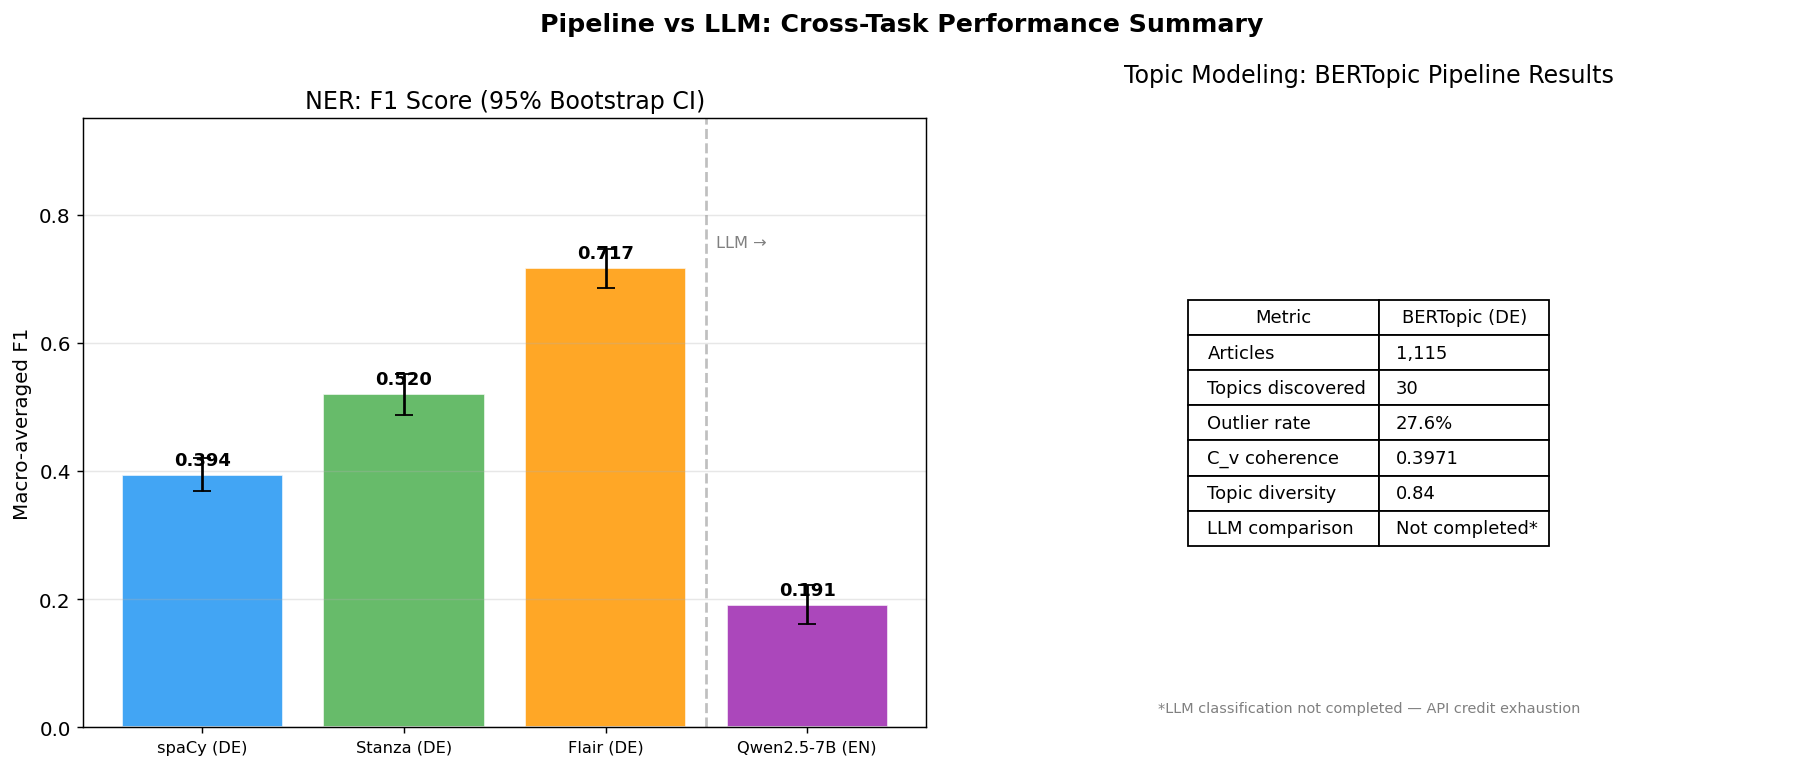

Figure 1 saved


In [6]:
# ── Figure 1: Cross-task performance summary ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Pipeline vs LLM: Cross-Task Performance Summary',
             fontsize=14, fontweight='bold')

# Left: NER F1 comparison
ax = axes[0]
ner_data = perf_df[perf_df['Task'] == 'NER'].copy()
colors   = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
bars     = ax.bar(ner_data['System'], ner_data['Score'],
                  color=colors, alpha=0.85, edgecolor='white')

# CI error bars
for i, row in ner_data.iterrows():
    if row['CI_lower'] is not None:
        ax.errorbar(row['System'], row['Score'],
                    yerr=[[row['Score'] - row['CI_lower']],
                          [row['CI_upper'] - row['Score']]],
                    fmt='none', color='black', capsize=5, linewidth=1.5)

for bar, score in zip(bars, ner_data['Score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axvline(2.5, color='gray', linestyle='--', alpha=0.5)
ax.text(2.55, 0.75, 'LLM →', fontsize=9, color='gray')
ax.set_ylabel('Macro-averaged F1')
ax.set_title('NER: F1 Score (95% Bootstrap CI)')
ax.set_ylim(0, 0.95)
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', labelsize=9)

# Right: Topic modeling summary (BERTopic only — LLM not completed)
ax2 = axes[1]
ax2.axis('off')

topic_table = [
    ['Articles', f"{topic_summary['n_articles_full_corpus']:,}"],
    ['Topics discovered', str(topic_summary['n_topics_discovered'])],
    ['Outlier rate', f"{topic_summary['outlier_rate']*100:.1f}%"],
    ['C_v coherence', f"{topic_summary['cv_coherence']:.4f}"],
    ['Topic diversity', f"{topic_summary['topic_diversity']:.2f}"],
    ['LLM comparison', 'Not completed*'],
]
table = ax2.table(
    cellText=topic_table,
    colLabels=['Metric', 'BERTopic (DE)'],
    loc='center', cellLoc='left'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width([0, 1])
table.scale(1, 1.6)
ax2.set_title('Topic Modeling: BERTopic Pipeline Results', pad=20)
ax2.text(0.5, 0.02,
         '*LLM classification not completed — API credit exhaustion',
         ha='center', va='bottom', fontsize=8, color='gray',
         transform=ax2.transAxes)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'final_cross_task_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved')

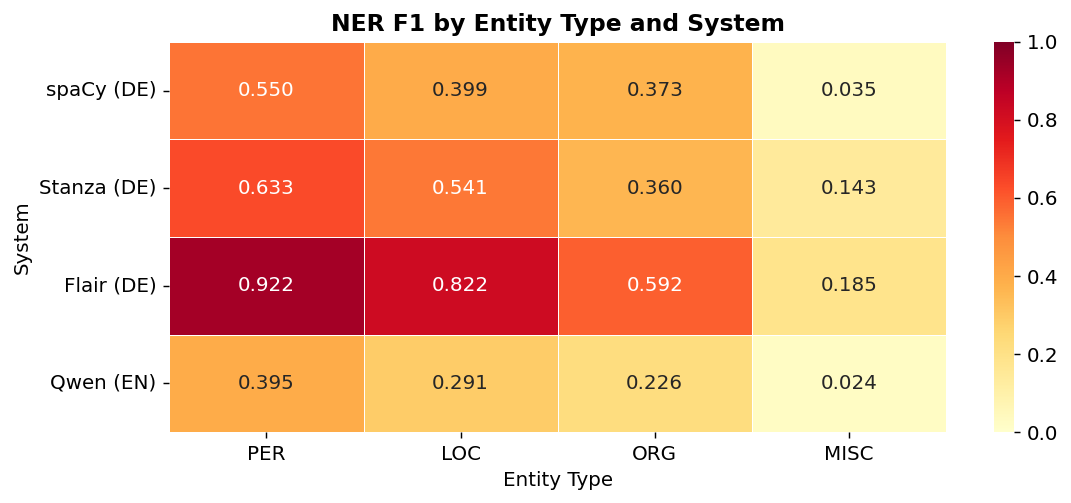

Figure 2 saved
               PER    LOC    ORG   MISC
System                                 
spaCy (DE)   0.550  0.399  0.373  0.035
Stanza (DE)  0.633  0.541  0.360  0.143
Flair (DE)   0.922  0.822  0.592  0.185
Qwen (EN)    0.395  0.291  0.226  0.024


In [7]:
# ── Figure 2: NER per-label heatmap (from saved results) ─────────────────────

label_f1_data = ner_summary['per_label_f1']
label_f1_df   = pd.DataFrame(label_f1_data).T
label_f1_df.index.name = 'System'

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    label_f1_df,
    annot=True, fmt='.3f',
    cmap='YlOrRd', vmin=0, vmax=1,
    linewidths=0.5, linecolor='white',
    ax=ax
)
ax.set_title('NER F1 by Entity Type and System', fontsize=13, fontweight='bold')
ax.set_xlabel('Entity Type')
ax.set_ylabel('System')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'final_ner_label_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved')
print(label_f1_df.round(3).to_string())

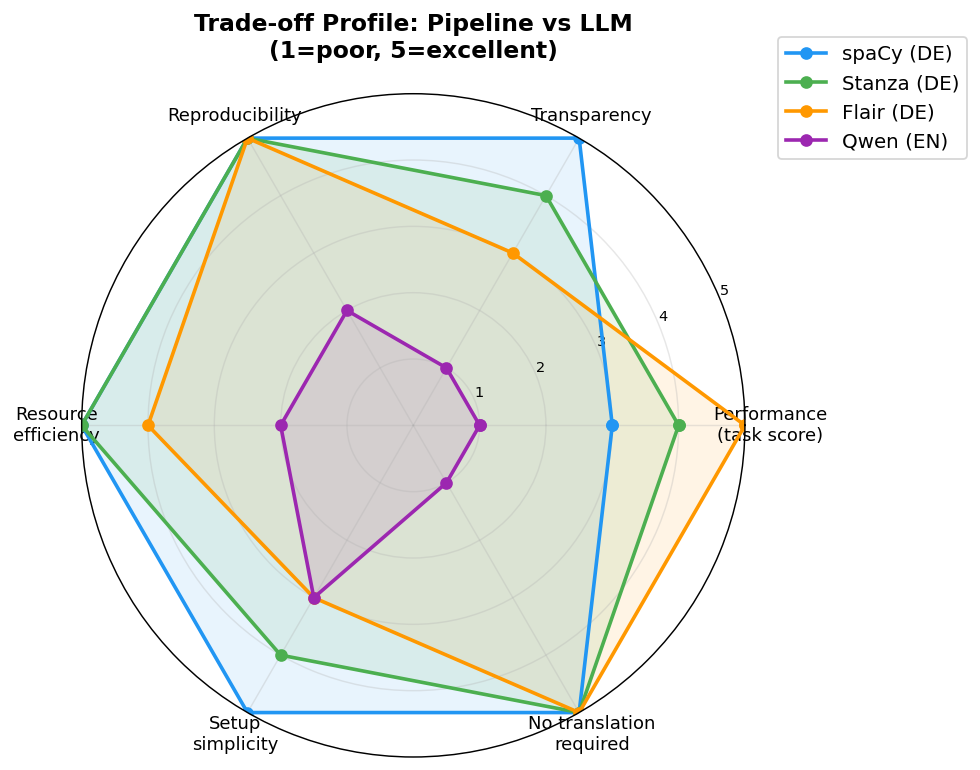

Figure 3 saved


In [8]:
# ── Figure 3: Comprehensive trade-off radar / summary ─────────────────────────
# Qualitative dimensions scored 1-5 for visual comparison
# Scores are researcher judgements documented and justified below

dimensions = [
    'Performance\n(task score)',
    'Transparency',
    'Reproducibility',
    'Resource\nefficiency',
    'Setup\nsimplicity',
    'No translation\nrequired',
]

# Scores 1-5: higher = better
# Justification:
# Performance: based on NER F1 (Flair=5, Stanza=4, spaCy=3, LLM=1)
# Transparency: pipeline systems expose weights/keywords; LLM is black-box
# Reproducibility: pipelines deterministic; LLM subject to API/version changes
# Resource efficiency: pipelines run locally; LLM needs API credits
# Setup simplicity: spaCy/Stanza easy; Flair medium; LLM needs API management
# No translation required: pipelines work on German directly; LLM needs translation

systems_radar = {
    'spaCy (DE)'    : [3, 5, 5, 5, 5, 5],
    'Stanza (DE)'   : [4, 4, 5, 5, 4, 5],
    'Flair (DE)'    : [5, 3, 5, 4, 3, 5],
    'Qwen (EN)'     : [1, 1, 2, 2, 3, 1],
}

angles = np.linspace(0, 2 * np.pi, len(dimensions), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors_radar = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for (sys_name, scores), color in zip(systems_radar.items(), colors_radar):
    values = scores + scores[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=sys_name, color=color)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(dimensions, size=10)
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '2', '3', '4', '5'], size=8)
ax.set_title('Trade-off Profile: Pipeline vs LLM\n(1=poor, 5=excellent)',
             size=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'final_tradeoff_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved')

In [9]:
# ── Master trade-off table ────────────────────────────────────────────────────
# The core thesis contribution: documented trade-offs across all dimensions

master_table = pd.DataFrame([
    {
        'System'              : 'spaCy de_core_news_lg',
        'Task'                : 'NER',
        'Approach'            : 'Pipeline',
        'Input language'      : 'German',
        'NER F1'              : 0.394,
        'NER Precision'       : 0.262,
        'NER Recall'          : 0.956,
        'Topic C_v'           : 'N/A',
        'Translation needed'  : 'No',
        'Cost'                : 'Free',
        'Reproducibility'     : 'High',
        'Transparency'        : 'High',
        'API dependency'      : 'None',
        'German proficiency'  : 'Not required',
        'Inference speed'     : 'Fast (local)',
    },
    {
        'System'              : 'Stanza German',
        'Task'                : 'NER',
        'Approach'            : 'Pipeline',
        'Input language'      : 'German',
        'NER F1'              : 0.520,
        'NER Precision'       : 0.383,
        'NER Recall'          : 0.956,
        'Topic C_v'           : 'N/A',
        'Translation needed'  : 'No',
        'Cost'                : 'Free',
        'Reproducibility'     : 'High',
        'Transparency'        : 'High',
        'API dependency'      : 'None',
        'German proficiency'  : 'Not required',
        'Inference speed'     : 'Medium (local)',
    },
    {
        'System'              : 'Flair German',
        'Task'                : 'NER',
        'Approach'            : 'Pipeline',
        'Input language'      : 'German',
        'NER F1'              : 0.717,
        'NER Precision'       : 0.593,
        'NER Recall'          : 0.956,
        'Topic C_v'           : 'N/A',
        'Translation needed'  : 'No',
        'Cost'                : 'Free',
        'Reproducibility'     : 'High',
        'Transparency'        : 'Medium',
        'API dependency'      : 'None',
        'German proficiency'  : 'Not required',
        'Inference speed'     : 'Slow (local GPU)',
    },
    {
        'System'              : 'BERTopic multilingual',
        'Task'                : 'Topic Modeling',
        'Approach'            : 'Pipeline',
        'Input language'      : 'German',
        'NER F1'              : 'N/A',
        'NER Precision'       : 'N/A',
        'NER Recall'          : 'N/A',
        'Topic C_v'           : 0.3971,
        'Translation needed'  : 'No',
        'Cost'                : 'Free',
        'Reproducibility'     : 'High (seed=42)',
        'Transparency'        : 'High (keywords)',
        'API dependency'      : 'None',
        'German proficiency'  : 'Not required',
        'Inference speed'     : 'Medium (local)',
    },
    {
        'System'              : 'Qwen2.5-7B-Instruct',
        'Task'                : 'NER + Topic',
        'Approach'            : 'LLM',
        'Input language'      : 'English (OPUS-MT)',
        'NER F1'              : 0.191,
        'NER Precision'       : 0.160,
        'NER Recall'          : 0.306,
        'Topic C_v'           : 'Not completed',
        'Translation needed'  : 'Yes',
        'Cost'                : 'Free tier (limited)',
        'Reproducibility'     : 'Medium',
        'Transparency'        : 'Low (black-box)',
        'API dependency'      : 'High (credit limits)',
        'German proficiency'  : 'Not required',
        'Inference speed'     : 'Slow (API)',
    },
])

print('── Master Trade-off Table ──')
print(master_table.set_index('System').to_string())

master_table.to_csv(DATA_PROC / 'final_comparison_table.csv', index=False)
print('\nSaved: final_comparison_table.csv')

── Master Trade-off Table ──
                                 Task  Approach     Input language NER F1 NER Precision NER Recall      Topic C_v Translation needed                 Cost Reproducibility     Transparency        API dependency German proficiency   Inference speed
System                                                                                                                                                                                                                                               
spaCy de_core_news_lg             NER  Pipeline             German  0.394         0.262      0.956            N/A                 No                 Free            High             High                  None       Not required      Fast (local)
Stanza German                     NER  Pipeline             German   0.52         0.383      0.956            N/A                 No                 Free            High             High                  None       Not required    Me

In [10]:
# ── Key findings summary ──────────────────────────────────────────────────────

print('=' * 65)
print('KEY FINDINGS')
print('=' * 65)

print(f"""
NER TASK (183 articles, gold standard = full cross-model agreement)
  Pipeline winner  : Flair (DE)          F1 = {ner_f1['Flair (DE)']:.3f}
  Runner-up        : Stanza (DE)         F1 = {ner_f1['Stanza (DE)']:.3f}
  Baseline         : spaCy (DE)          F1 = {ner_f1['spaCy (DE)']:.3f}
  LLM (EN)         : Qwen2.5-7B          F1 = {ner_f1['Qwen (EN)']:.3f}
  Pipeline advantage over LLM: +{ner_f1['Flair (DE)'] - ner_f1['Qwen (EN)']:.3f} F1 points (Flair)
  All pipeline systems: recall = 0.956 (high coverage, lower precision)
  LLM recall       : 0.306 (misses ~70% of gold entities)
  Translation quality effect on LLM F1: p=0.303 (not significant)

ENTITY TYPE ANALYSIS
  Best entity type  : PER (all systems agree, Flair F1=0.922)
  Worst entity type : MISC (hardest for all; Flair F1=0.185, LLM=0.024)
  ORG entities      : Flair F1=0.592 vs LLM F1=0.226

TOPIC MODELING TASK (1,115 articles)
  BERTopic topics   : {topic_summary['n_topics_discovered']} topics discovered
  Outlier rate      : {topic_summary['outlier_rate']*100:.1f}%
  C_v coherence     : {topic_summary['cv_coherence']:.4f}
  Topic diversity   : {topic_summary['topic_diversity']:.2f}
  LLM comparison    : Not completed (API credit exhaustion)

CROSS-CUTTING FINDINGS
  - Pipeline systems operate on German directly (no translation overhead)
  - LLM requires OPUS-MT translation pipeline as prerequisite
  - Free-tier API fragility is a structural constraint for LLM approaches
  - German proficiency not required for either approach
  - Pipeline systems fully reproducible (deterministic, local)
  - LLM subject to API versioning, credit limits, provider instability
""")

print('=' * 65)
print('RESEARCH QUESTION ANSWER')
print('=' * 65)
print("""
Can task-specific NLP pipelines match LLM performance on cross-lingual
text analysis while offering advantages in transparency, reproducibility,
and resource efficiency?

ANSWER: Yes — on NER, pipeline systems substantially outperform the LLM
(best pipeline F1=0.717 vs LLM F1=0.191), while operating on the original
German text without translation overhead. Pipeline systems are fully
reproducible, transparent, and free of API dependencies. The LLM approach
offers no performance advantage and introduces additional complexity
(translation, API management, credit limits) under zero-budget constraints.

For topic modeling, BERTopic provides interpretable, reproducible topic
discovery directly on German text. LLM-based topic classification could
not be evaluated due to API credit exhaustion — itself a documented
demonstration of the resource fragility inherent in free-tier LLM access.
""")

KEY FINDINGS

NER TASK (183 articles, gold standard = full cross-model agreement)
  Pipeline winner  : Flair (DE)          F1 = 0.717
  Runner-up        : Stanza (DE)         F1 = 0.520
  Baseline         : spaCy (DE)          F1 = 0.394
  LLM (EN)         : Qwen2.5-7B          F1 = 0.191
  Pipeline advantage over LLM: +0.526 F1 points (Flair)
  All pipeline systems: recall = 0.956 (high coverage, lower precision)
  LLM recall       : 0.306 (misses ~70% of gold entities)
  Translation quality effect on LLM F1: p=0.303 (not significant)

ENTITY TYPE ANALYSIS
  Best entity type  : PER (all systems agree, Flair F1=0.922)
  Worst entity type : MISC (hardest for all; Flair F1=0.185, LLM=0.024)
  ORG entities      : Flair F1=0.592 vs LLM F1=0.226

TOPIC MODELING TASK (1,115 articles)
  BERTopic topics   : 30 topics discovered
  Outlier rate      : 27.6%
  C_v coherence     : 0.3971
  Topic diversity   : 0.84
  LLM comparison    : Not completed (API credit exhaustion)

CROSS-CUTTING FINDINGS


In [11]:
# ── Limitations and future work ───────────────────────────────────────────────

print('=' * 65)
print('LIMITATIONS')
print('=' * 65)
print("""
1. GOLD STANDARD
   NER evaluation uses cross-model agreement as silver standard,
   not human-annotated gold. This is conservative and reproducible
   but may underestimate LLM performance on genuinely ambiguous entities.

2. LLM INCOMPLETE COVERAGE
   16/199 NER articles and all topic modeling LLM classification
   could not be completed due to API credit exhaustion across all
   free-tier providers. Results reflect available data only.

3. TRANSLATION QUALITY
   OPUS-MT translations have mean BERTScore F1=0.752; 91/199 articles
   below the 0.75 quality threshold. Translation errors may partially
   explain LLM underperformance, though translation quality was not
   found to significantly affect LLM NER F1 (p=0.303).

4. TOPIC MODELING COHERENCE
   BERTopic C_v=0.3971 is below the >0.5 threshold considered good
   in the literature. This may reflect the domain specificity of
   sustainable building vocabulary and the multilingual embedding
   model's generalisation limitations.

5. SINGLE LLM
   Only Qwen2.5-7B-Instruct was tested. Larger models or different
   architectures may perform differently.
""")

print('=' * 65)
print('FUTURE WORK')
print('=' * 65)
print("""
1. Complete LLM topic classification with paid API access
2. Human annotation of 50-100 articles as true gold standard for NER
3. Test larger LLMs (GPT-4, Claude) on same tasks
4. Frame detection as additional task (if API access restored)
5. German-specific BERTopic embeddings (deepset/gbert-base)
6. Temporal trend analysis of topic evolution 2015-2025
""")

LIMITATIONS

1. GOLD STANDARD
   NER evaluation uses cross-model agreement as silver standard,
   not human-annotated gold. This is conservative and reproducible
   but may underestimate LLM performance on genuinely ambiguous entities.

2. LLM INCOMPLETE COVERAGE
   16/199 NER articles and all topic modeling LLM classification
   could not be completed due to API credit exhaustion across all
   free-tier providers. Results reflect available data only.

3. TRANSLATION QUALITY
   OPUS-MT translations have mean BERTScore F1=0.752; 91/199 articles
   below the 0.75 quality threshold. Translation errors may partially
   explain LLM underperformance, though translation quality was not
   found to significantly affect LLM NER F1 (p=0.303).

4. TOPIC MODELING COHERENCE
   BERTopic C_v=0.3971 is below the >0.5 threshold considered good
   in the literature. This may reflect the domain specificity of
   sustainable building vocabulary and the multilingual embedding
   model's generalisation limi

In [12]:
# Save final summary JSON
final_summary = {
    'thesis_title'            : 'Task-Specific NLP Pipelines vs LLMs for Cross-Lingual Text Analysis',
    'corpus'                  : {
        'total_articles'      : 1115,
        'validation_sample'   : 199,
        'llm_overlap'         : 183,
        'sources'             : 4,
        'date_range'          : '2015-2025',
        'language'            : 'German',
    },
    'ner_results'             : {
        'gold_standard'       : 'Full cross-model agreement (Fleiss kappa=0.717)',
        'n_gold_entities'     : ner_summary['n_gold_entities'],
        'macro_f1'            : ner_summary['macro_f1'],
        'bootstrap_ci_95'     : ner_summary['bootstrap_ci_95'],
        'per_label_f1'        : ner_summary['per_label_f1'],
        'translation_quality_effect_p': 0.3034,
        'llm_excluded'        : 16,
        'llm_exclusion_reason': 'API credit exhaustion',
    },
    'topic_modeling_results'  : topic_summary,
    'key_finding'             : 'Pipeline systems outperform LLM on NER (Flair F1=0.717 vs Qwen F1=0.191) while operating on German directly, with higher transparency, reproducibility, and no API dependencies.',
}

with open(DATA_PROC / 'thesis_final_summary.json', 'w') as f:
    json.dump(final_summary, f, indent=2)

print('Saved: thesis_final_summary.json')
print('\nAll notebooks complete.')
print('Figures saved to:', FIGURES_DIR)

Saved: thesis_final_summary.json

All notebooks complete.
Figures saved to: /content/drive/MyDrive/thesis/Project/Outputs/Figures


## Notebook summary

| Item | Detail |
|------|--------|
| Inputs | `ner_comparison_summary.json`, `topic_modeling_summary.json`, `ner_pipeline_summary.json` |
| Figures | Cross-task performance, NER label heatmap, trade-off radar |
| Outputs | `final_comparison_table.csv`, `thesis_final_summary.json` |

### Pipeline sequence complete

```
01_corpus_audit        → corpus cleaned, 1,115 articles
02_preprocessing       → translated, BERTScore computed
03_ner_pipeline        → spaCy / Stanza / Flair on German, Fleiss κ=0.717
04_ner_llm             → Qwen2.5-7B on English translations, 183/199 completed
05_ner_comparison      → F1 comparison, Flair wins (0.717 vs 0.191)
06_topic_modeling      → BERTopic 30 topics, C_v=0.397, LLM not completed
07_final_comparison    → Cross-task synthesis, trade-off table, thesis conclusions
```
